# Analytic Wald Field on a Kerr Black Hole

This notebook plots the analytic Wald solution in Kerr-Schild coordinates for a chosen spin `a`.

The color map shows `log10(|A_phi|)` and the contour lines are levels of `A_phi`, which trace the poloidal magnetic field lines.

Adjust `a` in the last cell to compare different spins.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

In [2]:
def wald_ks_A0(a, r, sth, cth):
    return a * r * (1.0 + cth * cth) / (r * r + a * a * cth * cth) - a

def wald_ks_Aphi(a, r, sth, cth):
    return 0.5 * sth * sth * (
        r * r + a * a - 2.0 * a * a * r * (1.0 + cth * cth) / (r * r + a * a * cth * cth)
    )

def horizon_radius(a):
    return 1.0 + np.sqrt(max(0.0, 1.0 - a * a))

def _bilateral_pcolor_and_contours(ax, X, Z, F, levels, cmap="magma", contour_color="cyan"):
    im = None
    for sign in (1.0, -1.0):
        Xs = sign * X
        im = ax.pcolormesh(Xs, Z, F, shading="auto", cmap=cmap)
        ax.contour(Xs, Z, F, levels=levels, colors=contour_color, linewidths=0.7, alpha=0.75)
    return im

def plot_wald_field(a=0.998, r_max=95.0, n_r=600, n_th=700, levels=28, cmap="magma"):
    r_h = horizon_radius(a)
    r = np.linspace(r_h * 1.001, r_max, n_r)
    th = np.linspace(1.0e-4, np.pi - 1.0e-4, n_th)

    R, TH = np.meshgrid(r, th)
    sth = np.sin(TH)
    cth = np.cos(TH)

    # In axisymmetry, A_phi contours trace poloidal magnetic field lines.
    Aphi = wald_ks_Aphi(a, R, sth, cth)
    Aphi_abs = np.maximum(np.abs(Aphi), 1.0e-30)
    Aphi_log = np.log10(Aphi_abs)

    X = R * sth
    Z = R * cth

    finite = np.isfinite(Aphi_log)
    if np.any(finite):
        lo, hi = np.nanpercentile(Aphi_log[finite], [5, 95])
    else:
        lo, hi = -10.0, 2.0
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = -10.0, 2.0
    contour_levels = np.linspace(lo, hi, levels)

    fig, ax = plt.subplots(figsize=(11, 8), constrained_layout=True)
    im = _bilateral_pcolor_and_contours(ax, X, Z, Aphi_log, contour_levels, cmap=cmap)

    ax.add_patch(Circle((0.0, 0.0), r_h, color="black", zorder=5))
    ax.set_aspect("equal")
    ax.set_xlim(-r_max, r_max)
    ax.set_ylim(-r_max, r_max)
    ax.set_xlabel(r"$r / r_g$")
    ax.set_ylabel(r"$z / r_g$")
    ax.set_title(fr"Analytic Wald field (bilateral) | a={a:.3f} | $r_{{H}}$={r_h:.3f}")

    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label(r"$\log_{10}(|A_{\phi}|)$")

    return fig, ax

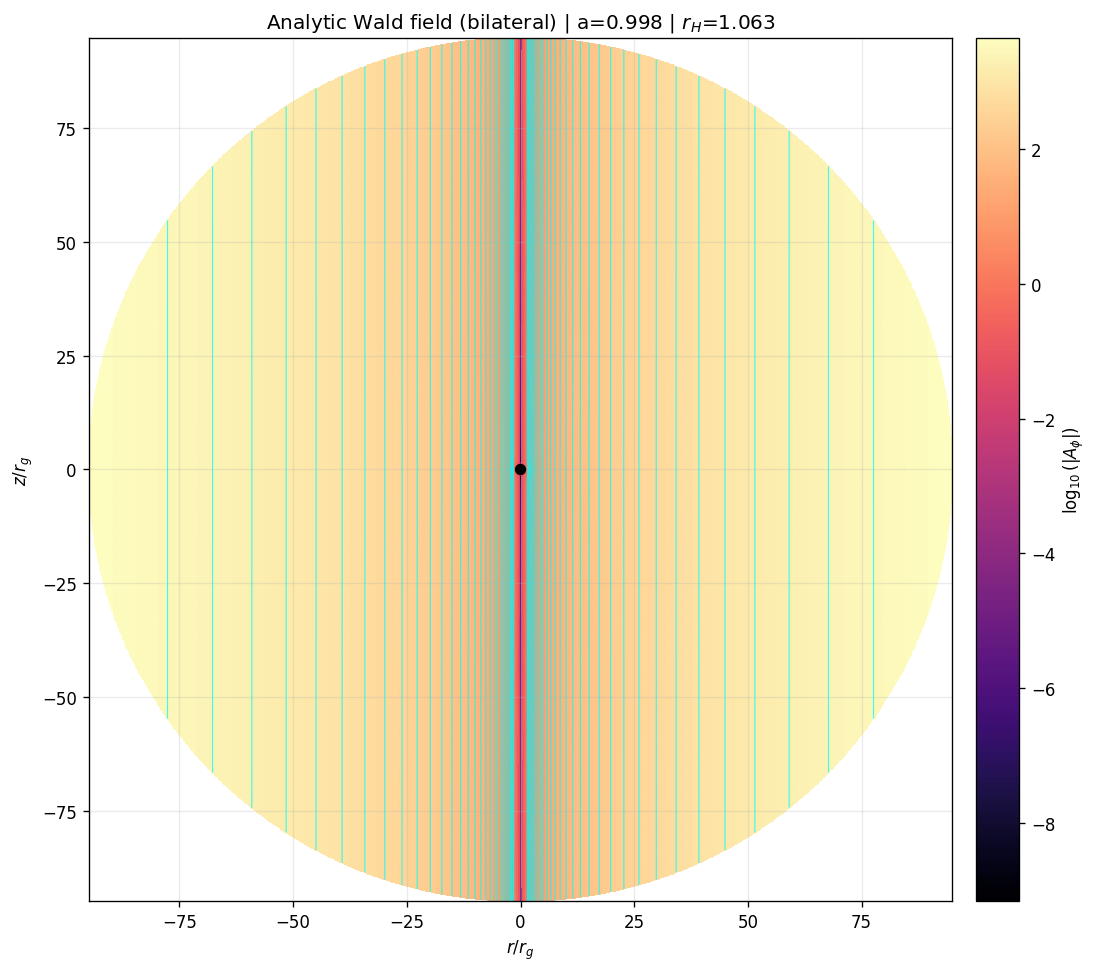

In [3]:
# Choose the spin here.
a = 0.998

# Plot extent and resolution.
r_max = 95.0
n_r = 600
n_th = 700

fig, ax = plot_wald_field(a=a, r_max=r_max, n_r=n_r, n_th=n_th, levels=30)
plt.show()

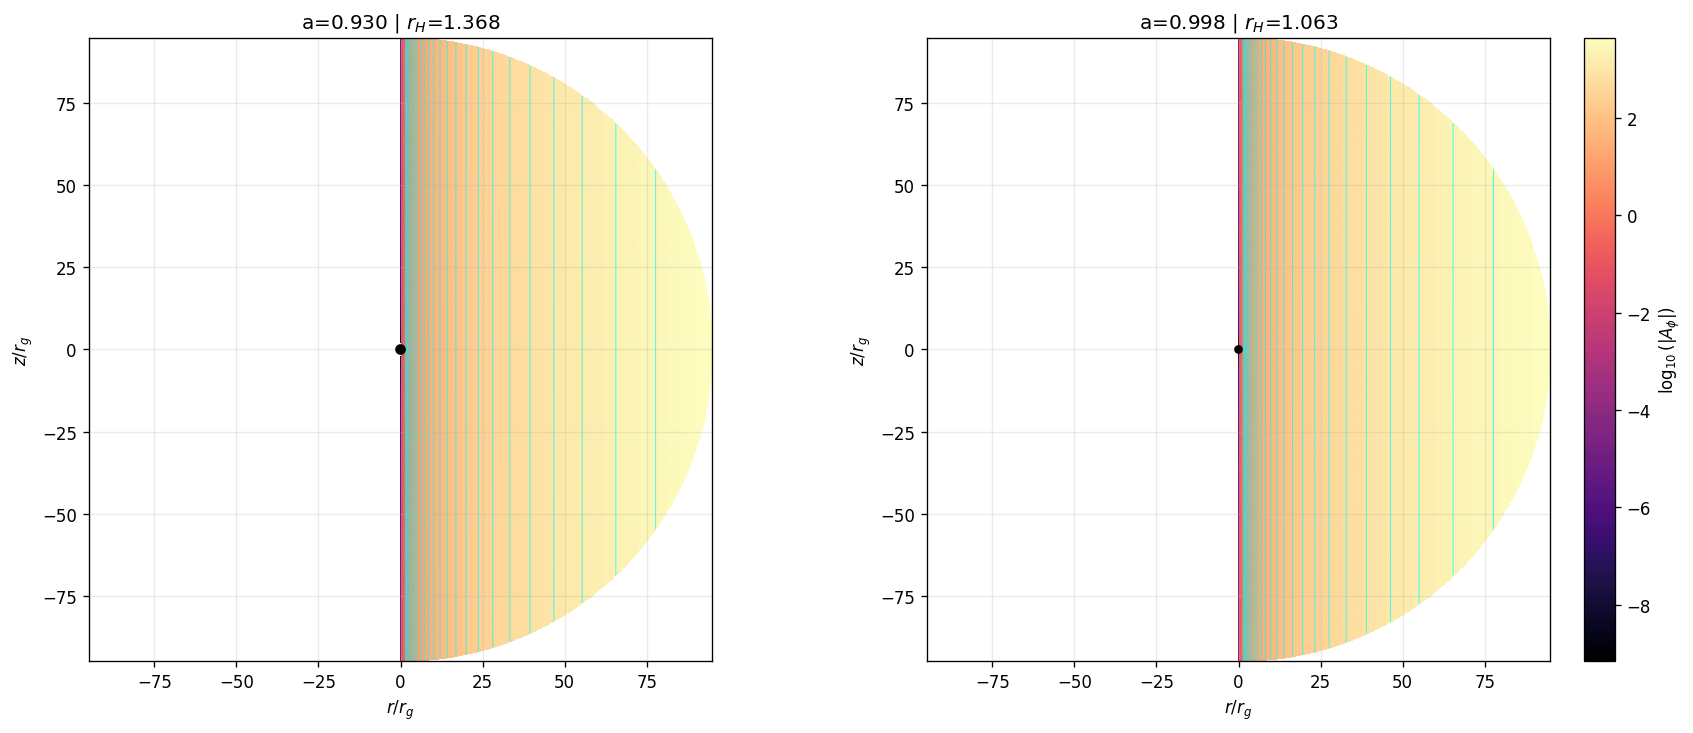

In [ ]:
# Optional quick comparison against a lower spin (both shown bilaterally).
compare_spins = [0.93, 0.998]
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

for ax, a in zip(axes, compare_spins):
    r_h = horizon_radius(a)
    r = np.linspace(r_h * 1.001, 95.0, 500)
    th = np.linspace(1.0e-4, np.pi - 1.0e-4, 600)
    R, TH = np.meshgrid(r, th)
    sth = np.sin(TH)
    cth = np.cos(TH)
    Aphi = wald_ks_Aphi(a, R, sth, cth)
    Aphi_log = np.log10(np.maximum(np.abs(Aphi), 1.0e-30))

    X = R * sth
    Z = R * cth
    finite = np.isfinite(Aphi_log)
    lo, hi = np.nanpercentile(Aphi_log[finite], [5, 95]) if np.any(finite) else (-10.0, 2.0)
    levels = np.linspace(lo, hi, 24)

    im = _bilateral_pcolor_and_contours(ax, X, Z, Aphi_log, levels, cmap="magma")

    ax.add_patch(Circle((0.0, 0.0), r_h, color="black", zorder=5))
    ax.set_aspect("equal")
    ax.set_xlim(-95.0, 95.0)
    ax.set_ylim(-95.0, 95.0)
    ax.set_title(fr"a={a:.3f} | $r_{{H}}$={r_h:.3f}")
    ax.set_xlabel(r"$r / r_g$")
    ax.set_ylabel(r"$z / r_g$")

fig.colorbar(im, ax=axes, pad=0.02, label=r"$\log_{10}(|A_{\phi}|)$")
plt.show()